<a href="https://colab.research.google.com/github/Sanmarquino/Modelos-Supervisado-y-No-Supervisados/blob/main/Machine_Learning_REINFO_Isolation_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Cargando la Base Maestra Final...

2. Tratamiento de Nulos (Imputación Estratégica)...

3. Verificando variables constantes (Varianza 0)...
-> Variables a eliminar por no aportar información: ['AÑO_VENTAS', 'ESTADO_REINFO']

4. Análisis de Multicolinealidad (Correlación de Pearson > 0.85)...
-> Alta correlación detectada: TOTAL_DENUNCIAS <--> DENUNCIAS_CON_ORDEN (r = 0.9986)
-> Alta correlación detectada: MAXIMO <--> VENTAS_ESTIMADAS_UIT (r = 0.9971)
-> Alta correlación detectada: LOC_PROMEDIO <--> LOC_MAX (r = 0.9940)
-> Alta correlación detectada: MINIMO <--> VENTAS_ESTIMADAS_UIT (r = 0.9933)
-> Alta correlación detectada: MINIMO <--> MAXIMO (r = 0.9816)
-> Alta correlación detectada: TOTAL_RESOLUCIONES <--> MONTO_MULTAS (r = 0.9304)
-> Alta correlación detectada: TRAB_PROMEDIO <--> TRAB_MAX (r = 0.8814)
-> Alta correlación detectada: LOC_MAX <--> DENUNCIAS_CON_ORDEN (r = 0.8788)
-> Alta correlación detectada: LOC_MAX <--> TOTAL_DENUNCIAS (r = 0.8725)
-> Alta correlación detectada

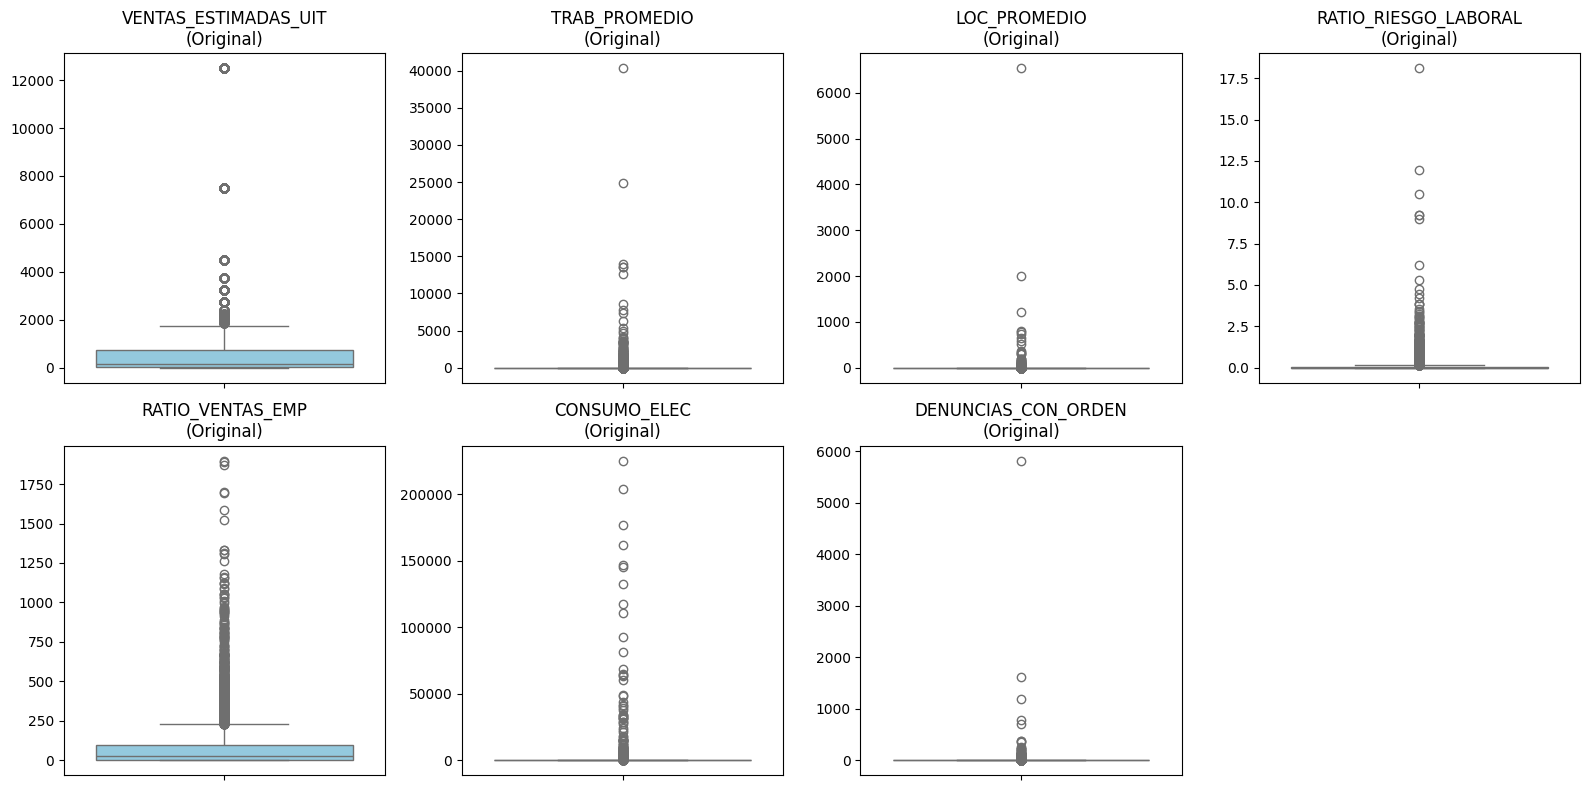

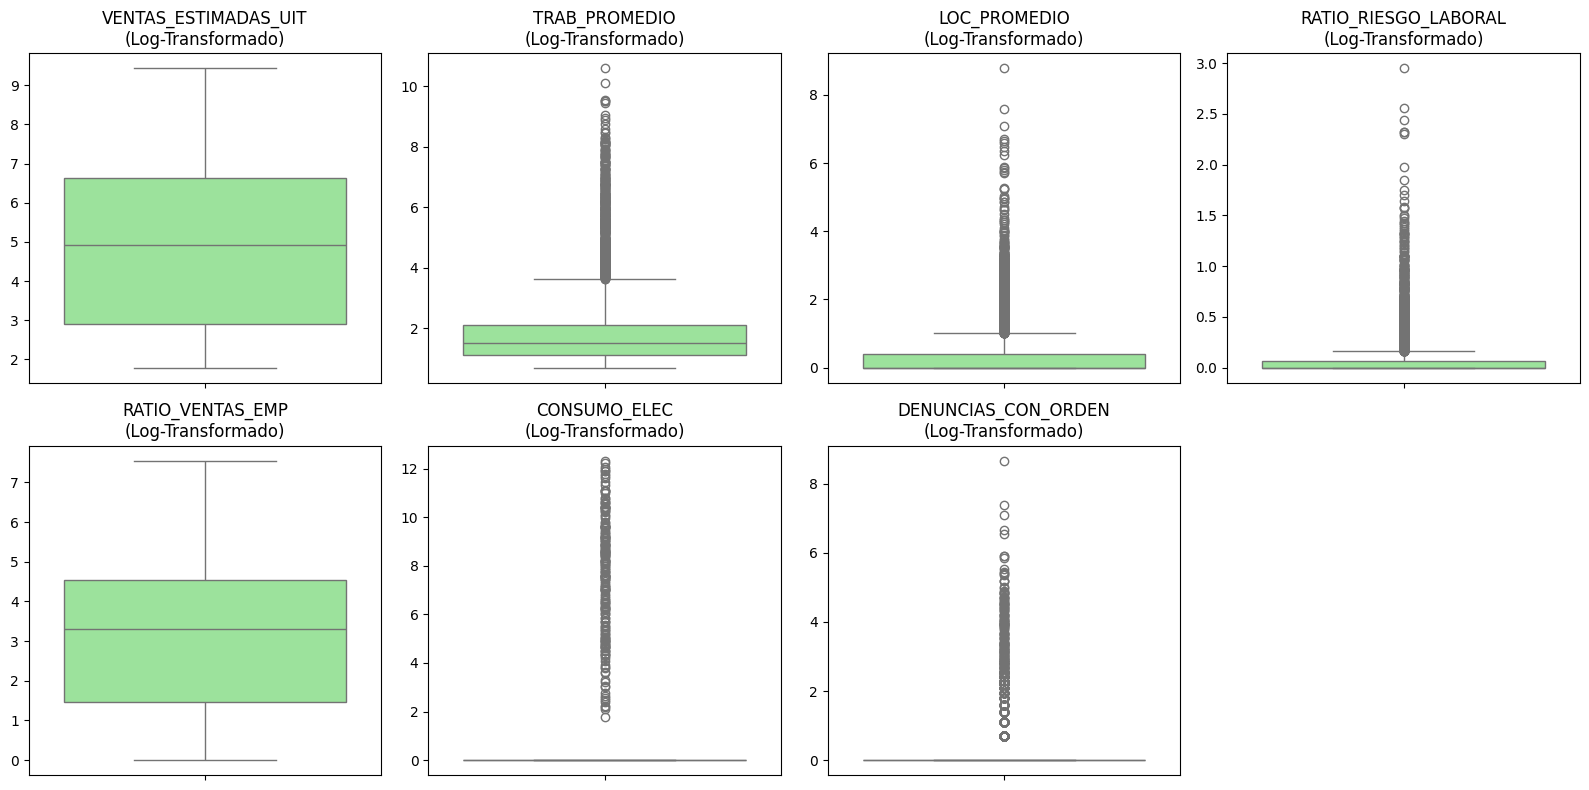


8. Exportando matriz final (8757 filas x 11 columnas) a Excel...
¡Éxito! Archivo guardado como 'BASE_FINAL_MODELO_REINFO.xlsx'. Listo para Isolation Forest.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# FASE 1: CARGA DE DATOS Y LIMPIEZA INICIAL
# ==========================================
print("1. Cargando la Base Maestra Final...")
df = pd.read_csv("/content/BASE_MAESTRA_FINAL_REINFO.csv")

# Limpieza de seguridad: Elimina espacios ocultos en los nombres de las columnas
df.columns = df.columns.str.strip()

# ==========================================
# FASE 2: TRATAMIENTO DE NULOS
# ==========================================
print("\n2. Tratamiento de Nulos (Imputación Estratégica)...")
if 'UTILIDADES' in df.columns:
    df['UTILIDADES'] = df['UTILIDADES'].fillna('NO_DECLARA')
# Las variables geográficas con 97% nulos (IRE, PROVINCIA) se ignoran pues no irán al modelo.

# ==========================================
# FASE 3: ANÁLISIS DE VARIANZA CERO
# ==========================================
print("\n3. Verificando variables constantes (Varianza 0)...")
const_vars = [col for col in df.columns if df[col].nunique() <= 1]
print(f"-> Variables a eliminar por no aportar información: {const_vars}")

# ==========================================
# FASE 4: ANÁLISIS DE MULTICOLINEALIDAD
# ==========================================
print("\n4. Análisis de Multicolinealidad (Correlación de Pearson > 0.85)...")
vars_numericas_todas = df.select_dtypes(include=[np.number]).columns.tolist()
# Quitamos el RUC, el Target y las variables constantes del análisis
vars_numericas_todas = [c for c in vars_numericas_todas if c not in ['RUC', 'TARGET_INCUMPLIMIENTO'] + const_vars]

corr_matrix = df[vars_numericas_todas].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(upper_tri.index[i], upper_tri.columns[j], upper_tri.iloc[i, j])
                   for i in range(len(upper_tri.index))
                   for j in range(len(upper_tri.columns))
                   if upper_tri.iloc[i, j] > 0.85]

for var1, var2, corr_val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
    print(f"-> Alta correlación detectada: {var1} <--> {var2} (r = {corr_val:.4f})")

# ==========================================
# FASE 5: FEATURE SELECTION (LAS 10 VARIABLES)
# ==========================================
print("\n5. Seleccionando las 10 variables definitivas (Libres de multicolinealidad)...")
vars_numericas_finales = [
    'VENTAS_ESTIMADAS_UIT',
    'TRAB_PROMEDIO',
    'LOC_PROMEDIO',
    'RATIO_RIESGO_LABORAL',
    'RATIO_VENTAS_EMP',
    'CONSUMO_ELEC',
    'DENUNCIAS_CON_ORDEN'
]

vars_categoricas_finales = [
    'TAMAÑO',
    'UTILIDADES',
    'INDICE_MULTIREGION'
]

# Consolidamos el dataset final
columnas_modelo = ['RUC'] + vars_numericas_finales + vars_categoricas_finales
df_model = df[columnas_modelo].copy()

# ==========================================
# FASE 6: ANÁLISIS DESCRIPTIVO DE LA DATA CURADA
# ==========================================
print("\n6. Estadísticas Descriptivas (Asimetría y Curtosis)...")
desc_stats = pd.DataFrame()
desc_stats['Media'] = df_model[vars_numericas_finales].mean()
desc_stats['Mediana'] = df_model[vars_numericas_finales].median()
desc_stats['Desv. Estándar'] = df_model[vars_numericas_finales].std()
desc_stats['Asimetría (Skewness)'] = df_model[vars_numericas_finales].skew()
desc_stats['Curtosis'] = df_model[vars_numericas_finales].kurtosis()
print(desc_stats.round(2))

print("\n-> Frecuencias de Variables Categóricas:")
for col in vars_categoricas_finales:
    print(f"\n{col}:")
    print((df_model[col].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

# ==========================================
# FASE 7: ANÁLISIS VISUAL DE OUTLIERS (BOXPLOTS)
# ==========================================
print("\n7. Generando Boxplots (Originales vs Transformación Logarítmica)...")

# 7.1 Boxplots en escala original
plt.figure(figsize=(16, 8))
for i, col in enumerate(vars_numericas_finales, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df_model[col], color='skyblue')
    plt.title(f"{col}\n(Original)")
    plt.ylabel('')
plt.tight_layout()
plt.show()

# 7.2 Boxplots con Transformación Logarítmica (Para visualizar mejor las colas largas)
# Usamos log1p (log(1+x)) porque tenemos muchos valores en cero
plt.figure(figsize=(16, 8))
for i, col in enumerate(vars_numericas_finales, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=np.log1p(df_model[col]), color='lightgreen')
    plt.title(f"{col}\n(Log-Transformado)")
    plt.ylabel('')
plt.tight_layout()
plt.show()

# ==========================================
# FASE 8: EXPORTACIÓN PARA EL MODELO
# ==========================================
nombre_archivo_excel = "BASE_FINAL_MODELO_REINFO.xlsx"
print(f"\n8. Exportando matriz final ({df_model.shape[0]} filas x {df_model.shape[1]} columnas) a Excel...")
df_model.to_excel(nombre_archivo_excel, index=False, engine='openpyxl')
print(f"¡Éxito! Archivo guardado como '{nombre_archivo_excel}'. Listo para Isolation Forest.")

In [ ]:
import pandas as pd
import numpy as np

# 1. Cargar la data final limpia que ya curamos
print("Cargando la base de 10 variables...")
df = pd.read_excel("/content/BASE_FINAL_MODELO_REINFO.xlsx")

# 2. SEPARAR LAS VARIABLES POR SU NATURALEZA
vars_categoricas = ['TAMAÑO', 'UTILIDADES']
vars_numericas = [
    'VENTAS_ESTIMADAS_UIT',
    'TRAB_PROMEDIO',
    'LOC_PROMEDIO',
    'RATIO_RIESGO_LABORAL',
    'RATIO_VENTAS_EMP',
    'CONSUMO_ELEC',
    'DENUNCIAS_CON_ORDEN'
]
# INDICE_MULTIREGION y RUC no se tocan.

# 3. TRANSFORMACIÓN 1: ONE-HOT ENCODING (Dummificación)
print("Aplicando One-Hot Encoding a variables categóricas...")
# pd.get_dummies expande las categorías a columnas binarias (0 y 1)
df_encoded = pd.get_dummies(df, columns=vars_categoricas, dtype=int)

# 4. TRANSFORMACIÓN 2: LOGARÍTMICA (Log1p)
print("Aplicando transformación Log1p a variables numéricas sesgadas...")
for col in vars_numericas:
    # Creamos la nueva columna con el sufijo _LOG
    df_encoded[col + '_LOG'] = np.log1p(df_encoded[col])
    # Eliminamos la columna original cruda para no generar multicolinealidad
    df_encoded = df_encoded.drop(columns=[col])

# 5. LIMPIEZA DE NOMBRES DE COLUMNAS
# Quitamos espacios que genera el get_dummies para evitar errores en ciertos algoritmos
df_encoded.columns = [c.replace(' ', '_').replace('.', '') for c in df_encoded.columns]

# 6. REVISIÓN Y EXPORTACIÓN FINAL
print("\n--- FORMA DE LA MATRIZ TRANSFORMADA ---")
print(f"Filas: {df_encoded.shape[0]} | Columnas: {df_encoded.shape[1]}")

print("\n--- NUEVAS COLUMNAS LISTAS PARA EL MODELO ---")
for i, col in enumerate(df_encoded.columns, 1):
    print(f"{i}. {col}")

# Guardar el tensor matemático final
nombre_salida = "BASE_TRANSFORMADA_ISOLATION_FOREST.csv"
df_encoded.to_csv(nombre_salida, index=False)
print(f"\n¡Transformación exitosa! Matriz guardada como: {nombre_salida}")

Cargando la base de 10 variables...
Aplicando One-Hot Encoding a variables categóricas...
Aplicando transformación Log1p a variables numéricas sesgadas...

--- FORMA DE LA MATRIZ TRANSFORMADA ---
Filas: 8757 | Columnas: 16

--- NUEVAS COLUMNAS LISTAS PARA EL MODELO ---
1. RUC
2. INDICE_MULTIREGION
3. TAMAÑO_GRAN_EMPRESA
4. TAMAÑO_MEDIANA_EMPRESA
5. TAMAÑO_MICROEMPRESA
6. TAMAÑO_PEQUEÑA_EMPRESA
7. UTILIDADES_NO
8. UTILIDADES_NO_DECLARA
9. UTILIDADES_SI
10. VENTAS_ESTIMADAS_UIT_LOG
11. TRAB_PROMEDIO_LOG
12. LOC_PROMEDIO_LOG
13. RATIO_RIESGO_LABORAL_LOG
14. RATIO_VENTAS_EMP_LOG
15. CONSUMO_ELEC_LOG
16. DENUNCIAS_CON_ORDEN_LOG

¡Transformación exitosa! Matriz guardada como: BASE_TRANSFORMADA_ISOLATION_FOREST.csv


Cargando la matriz transformada: BASE_TRANSFORMADA_ISOLATION_FOREST.csv...

--- ANÁLISIS DE VARIABLES CONTINUAS (LOG TRANSFORMADAS) ---
                           Media  Mediana  Desv_Std  Asimetria (Skewness)  Curtosis     Min      Max
VENTAS_ESTIMADAS_UIT_LOG  4.8225   4.9309    2.2467                0.0662   -1.1240  1.7918   9.4336
TRAB_PROMEDIO_LOG         1.7926   1.5222    1.1242                2.6875   10.0020  0.6931  10.6051
LOC_PROMEDIO_LOG          0.3738   0.0000    0.7351                3.1543   14.2611  0.0000   8.7853
RATIO_RIESGO_LABORAL_LOG  0.0753   0.0000    0.1817                5.0848   39.7543  0.0000   2.9505
RATIO_VENTAS_EMP_LOG      3.1814   3.3048    1.7365               -0.0204   -1.0920  0.0001   7.5495
CONSUMO_ELEC_LOG          0.1726   0.0000    1.1853                7.2447   53.4759  0.0000  12.3255
DENUNCIAS_CON_ORDEN_LOG   0.1483   0.0000    0.6089                5.5912   37.8135  0.0000   8.6691

--- ANÁLISIS DE MULTICOLINEALIDAD (MATRIZ COMPLETA SIN 

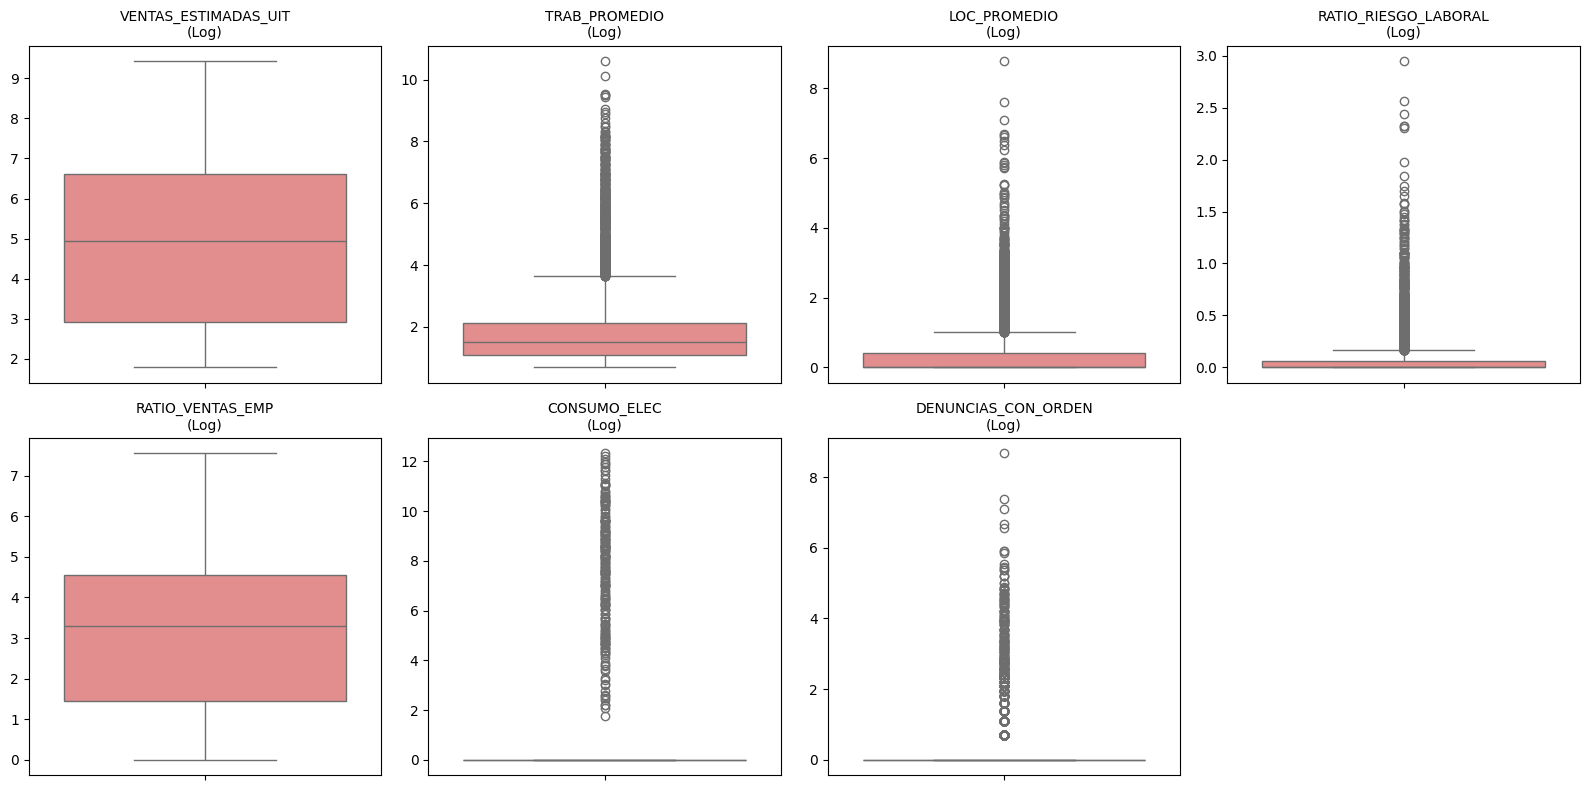


Generando Histogramas de Distribución...


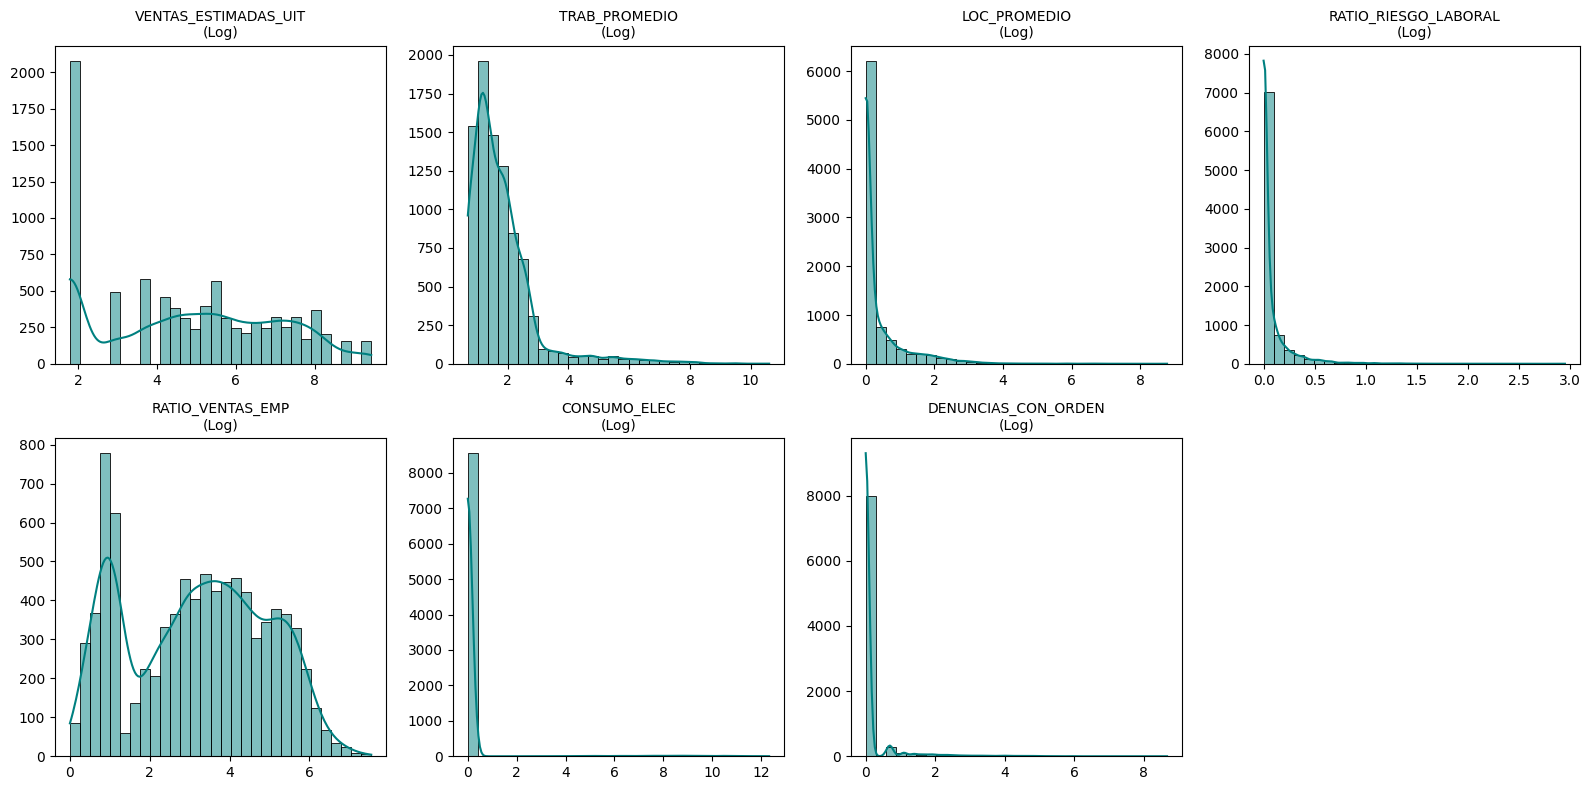


¡Análisis completado! Revisa los gráficos y la alerta de correlación arriba.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CARGA DE LA BASE TRANSFORMADA
# ==========================================
# Asegúrate de que el nombre coincida con el archivo que subiste a Colab
archivo = "BASE_TRANSFORMADA_ISOLATION_FOREST.csv" # o "BASE_TRANSFORMADA_ISOLATION_FOREST (1).csv"
print(f"Cargando la matriz transformada: {archivo}...\n")
df = pd.read_csv(archivo)

# Separar variables continuas (las que terminan en _LOG) de las binarias
vars_log = [col for col in df.columns if col.endswith('_LOG')]

# ==========================================
# 2. ESTADÍSTICAS DESCRIPTIVAS (El milagro de Log1p)
# ==========================================
print("--- ANÁLISIS DE VARIABLES CONTINUAS (LOG TRANSFORMADAS) ---")
desc_stats = pd.DataFrame({
    'Media': df[vars_log].mean(),
    'Mediana': df[vars_log].median(),
    'Desv_Std': df[vars_log].std(),
    'Asimetria (Skewness)': df[vars_log].skew(),
    'Curtosis': df[vars_log].kurtosis(),
    'Min': df[vars_log].min(),
    'Max': df[vars_log].max()
})
# Mostrar resultados redondeados a 4 decimales
print(desc_stats.round(4).to_string())

# ==========================================
# 3. ALERTA DE MULTICOLINEALIDAD (Toda la Matriz)
# ==========================================
print("\n--- ANÁLISIS DE MULTICOLINEALIDAD (MATRIZ COMPLETA SIN RUC) ---")
# Quitamos el RUC porque es un identificador, no un predictor
df_corr = df.drop(columns=['RUC'])
corr_matrix = df_corr.corr().abs()

# Extraer pares con correlación mayor a 0.80
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(upper_tri.index[i], upper_tri.columns[j], upper_tri.iloc[i, j])
                   for i in range(len(upper_tri.index))
                   for j in range(len(upper_tri.columns))
                   if upper_tri.iloc[i, j] > 0.80]

if high_corr_pairs:
    for var1, var2, corr_val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
         print(f"ALERTA (r > 0.80): {var1} <--> {var2} : {corr_val:.4f}")
else:
    print("ÉXITO: Ninguna variable supera la correlación de 0.80.")

# ==========================================
# 4. DIAGRAMAS DE CAJAS (BOXPLOTS)
# ==========================================
print("\nGenerando Diagramas de Cajas...")
plt.figure(figsize=(16, 8))
for i, col in enumerate(vars_log, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(col.replace('_LOG', '\n(Log)'), fontsize=10)
    plt.ylabel('')
plt.tight_layout()
plt.show()

# ==========================================
# 5. DIAGRAMAS DE DISTRIBUCIÓN (HISTOGRAMAS + KDE)
# ==========================================
print("\nGenerando Histogramas de Distribución...")
plt.figure(figsize=(16, 8))
for i, col in enumerate(vars_log, 1):
    plt.subplot(2, 4, i)
    # kde=True dibuja la curva de campana (o su intento) sobre las barras
    sns.histplot(df[col], kde=True, bins=30, color='teal')
    plt.title(col.replace('_LOG', '\n(Log)'), fontsize=10)
    plt.ylabel('')
    plt.xlabel('')
plt.tight_layout()
plt.show()

print("\n¡Análisis completado! Revisa los gráficos y la alerta de correlación arriba.")

In [ ]:
import pandas as pd

# ==========================================
# 1. CARGA DE LA MATRIZ TRANSFORMADA
# ==========================================
# Cargar el archivo que arrojó las alertas de multicolinealidad
archivo = "/content/BASE_TRANSFORMADA_ISOLATION_FOREST.csv" # o "BASE_TRANSFORMADA_ISOLATION_FOREST (1).csv"
print(f"Cargando {archivo}...")
df = pd.read_csv(archivo)

# ==========================================
# 2. PODA QUIRÚRGICA (ELIMINACIÓN DE REDUNDANCIAS)
# ==========================================
# Lista de las variables altamente correlacionadas que vamos a extirpar
columnas_a_eliminar = [
    'TAMAÑO_MICROEMPRESA',
    'TAMAÑO_PEQUEÑA_EMPRESA',
    'TAMAÑO_MEDIANA_EMPRESA',
    'TAMAÑO_GRAN_EMPRESA',
    'RATIO_VENTAS_EMP_LOG'
]

print("\nEliminando variables que causan multicolinealidad (r > 0.80)...")
for col in columnas_a_eliminar:
    print(f" -> Borrando: {col}")

# Crear el dataframe definitivo eliminando esas columnas
df_final = df.drop(columns=columnas_a_eliminar)

# ==========================================
# 3. VERIFICACIÓN Y EXPORTACIÓN DEL TENSOR ORO
# ==========================================
print("\n--- MATRIZ FINAL DESPUÉS DE LA PODA ---")
print(f"Filas: {df_final.shape[0]} | Columnas: {df_final.shape[1]}")

print("\n--- LAS 11 VARIABLES DEFINITIVAS (1 Identificador + 10 Predictoras Ortogonales) ---")
for i, col in enumerate(df_final.columns, 1):
    print(f"{i}. {col}")

# Exportar para asegurar el trabajo antes de modelar
nombre_salida = "BASE_MODELO_FINAL_PODA.csv"
df_final.to_csv(nombre_salida, index=False)
print(f"\n¡Operación exitosa! Data guardada como '{nombre_salida}'.")

Cargando /content/BASE_TRANSFORMADA_ISOLATION_FOREST.csv...

Eliminando variables que causan multicolinealidad (r > 0.80)...
 -> Borrando: TAMAÑO_MICROEMPRESA
 -> Borrando: TAMAÑO_PEQUEÑA_EMPRESA
 -> Borrando: TAMAÑO_MEDIANA_EMPRESA
 -> Borrando: TAMAÑO_GRAN_EMPRESA
 -> Borrando: RATIO_VENTAS_EMP_LOG

--- MATRIZ FINAL DESPUÉS DE LA PODA ---
Filas: 8757 | Columnas: 11

--- LAS 11 VARIABLES DEFINITIVAS (1 Identificador + 10 Predictoras Ortogonales) ---
1. RUC
2. INDICE_MULTIREGION
3. UTILIDADES_NO
4. UTILIDADES_NO_DECLARA
5. UTILIDADES_SI
6. VENTAS_ESTIMADAS_UIT_LOG
7. TRAB_PROMEDIO_LOG
8. LOC_PROMEDIO_LOG
9. RATIO_RIESGO_LABORAL_LOG
10. CONSUMO_ELEC_LOG
11. DENUNCIAS_CON_ORDEN_LOG

¡Operación exitosa! Data guardada como 'BASE_MODELO_FINAL_PODA.csv'.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

# ==============================================================================
# FASE 1: INGESTA DE LA DATA PURIFICADA
# ==============================================================================
print("1. Iniciando Ingesta de Datos...")
archivo_modelo = "/content/BASE_MODELO_FINAL_PODA.csv"
df = pd.read_csv(archivo_modelo)

# Separamos el identificador (RUC) de la matriz de entrenamiento (X)
identificador = df[['RUC']].copy()
X = df.drop(columns=['RUC'])

print(f" -> Matriz X lista para entrenar: {X.shape[0]} empresas x {X.shape[1]} variables.")

# ==============================================================================
# FASE 2: INSTANCIACIÓN Y ENTRENAMIENTO DEL MODELO NO SUPERVISADO
# ==============================================================================
print("\n2. Entrenando el modelo Isolation Forest...")
# Configuración: 100 árboles, 10% de contaminación esperada, semilla fija para auditoría
modelo_if = IsolationForest(
    n_estimators=100,
    contamination=0.10,
    random_state=42,
    n_jobs=-1 # Usar todos los núcleos del procesador
)

# El modelo "aprende" qué es lo normal y qué es anómalo
modelo_if.fit(X)

# ==============================================================================
# FASE 3: EXTRACCIÓN DE RESULTADOS MATEMÁTICOS
# ==============================================================================
print("3. Calculando Scores de Anomalía...")
# decision_function arroja scores crudos. Menor valor = Más anómalo.
scores_crudos = modelo_if.decision_function(X)

# Invertimos el signo para que "Mayor valor = Mayor Anomalía" (facilita la lectura)
scores_invertidos = scores_crudos * -1

# ==============================================================================
# FASE 4: TRANSFORMACIÓN A PROBABILIDAD DE INCUMPLIMIENTO (0% - 100%)
# ==============================================================================
print("4. Transformando Scores a Probabilidad de Incumplimiento (0-100%)...")
scaler = MinMaxScaler(feature_range=(0, 100))
# MinMaxScaler requiere un array 2D, por eso usamos reshape
probabilidades = scaler.fit_transform(scores_invertidos.reshape(-1, 1)).flatten()

# Añadimos los resultados al dataframe identificador
identificador['SCORE_CRUDO'] = scores_crudos
identificador['PROBABILIDAD_INCUMPLIMIENTO_%'] = np.round(probabilidades, 2)

# ==============================================================================
# FASE 5: SEGMENTACIÓN ESTRATÉGICA Y CLASIFICACIÓN DE RIESGO
# ==============================================================================
print("5. Aplicando reglas de negocio para clasificar el Nivel de Riesgo...")
# Usamos percentiles estadísticos para segmentar la base exactamente
percentil_95 = np.percentile(identificador['PROBABILIDAD_INCUMPLIMIENTO_%'], 95)
percentil_85 = np.percentile(identificador['PROBABILIDAD_INCUMPLIMIENTO_%'], 85)
percentil_70 = np.percentile(identificador['PROBABILIDAD_INCUMPLIMIENTO_%'], 70)

def asignar_riesgo(prob):
    if prob >= percentil_95:
        return 'MUY ALTO RIESGO'
    elif prob >= percentil_85:
        return 'ALTO RIESGO'
    elif prob >= percentil_70:
        return 'RIESGO MEDIO'
    else:
        return 'RIESGO BAJO'

identificador['NIVEL_DE_RIESGO'] = identificador['PROBABILIDAD_INCUMPLIMIENTO_%'].apply(asignar_riesgo)

# Ordenamos la tabla de mayor a menor riesgo para tener a los peores arriba
resultado_final = identificador.sort_values(by='PROBABILIDAD_INCUMPLIMIENTO_%', ascending=False).reset_index(drop=True)

# ==============================================================================
# FASE 6: REPORTE GERENCIAL Y EXPORTACIÓN
# ==============================================================================
print("\n================ RESUMEN GERENCIAL ================")
print(resultado_final['NIVEL_DE_RIESGO'].value_counts())
print("===================================================")

# Opcional: Mostramos el TOP 5 para visualización rápida
print("\nTop 5 Empresas con mayor probabilidad de incumplimiento:")
print(resultado_final.head(5).to_string(index=False))

# Guardamos el entregable final
nombre_entregable = "RESULTADO_FINAL_ISOLATION_FOREST.xlsx"
resultado_final.to_excel(nombre_entregable, index=False, engine='openpyxl')
print(f"\n¡MODELADO EXITOSO! Entregable gerencial guardado como '{nombre_entregable}'.")

1. Iniciando Ingesta de Datos...
 -> Matriz X lista para entrenar: 8757 empresas x 10 variables.

2. Entrenando el modelo Isolation Forest...
3. Calculando Scores de Anomalía...
4. Transformando Scores a Probabilidad de Incumplimiento (0-100%)...
5. Aplicando reglas de negocio para clasificar el Nivel de Riesgo...

================ RESUMEN GERENCIAL ================
NIVEL_DE_RIESGO
RIESGO BAJO        6126
RIESGO MEDIO       1316
ALTO RIESGO         877
MUY ALTO RIESGO     438
Name: count, dtype: int64

Top 5 Empresas con mayor probabilidad de incumplimiento:
        RUC  SCORE_CRUDO  PROBABILIDAD_INCUMPLIMIENTO_% NIVEL_DE_RIESGO
20131373075    -0.240632                         100.00 MUY ALTO RIESGO
20101259014    -0.239044                          99.63 MUY ALTO RIESGO
20131365994    -0.234828                          98.64 MUY ALTO RIESGO
20537630222    -0.233777                          98.40 MUY ALTO RIESGO
20131372931    -0.232204                          98.03 MUY ALTO RIESGO

¡M

In [ ]:
import pandas as pd

# ==============================================================================
# FASE 1: CARGA DE LAS DOS BASES
# ==============================================================================
print("1. Cargando las bases para el cruce de validación...")
# La base que acabamos de crear con las probabilidades (Tu entregable final)
df_resultados = pd.read_excel("/content/RESULTADO_FINAL_ISOLATION_FOREST.xlsx") # Asegura usar el nombre exacto de tu archivo

# La base maestra original que contiene a los 49 multados ocultos (Target = 1)
df_maestra = pd.read_csv("BASE_MAESTRA_FINAL_REINFO.csv")

# Limpieza de espacios en columnas por seguridad
df_maestra.columns = df_maestra.columns.str.strip()

# ==============================================================================
# FASE 2: EL CRUCE DE VALIDACIÓN (INNER JOIN)
# ==============================================================================
print("2. Cruzando las probabilidades de la IA con la realidad histórica...")
# Unimos la etiqueta "TARGET_INCUMPLIMIENTO" a nuestra tabla de resultados usando el RUC
df_cruce = pd.merge(df_resultados, df_maestra[['RUC', 'TARGET_INCUMPLIMIENTO']], on='RUC', how='left')

# Filtramos la tabla para quedarnos ÚNICAMENTE con los 49 infractores reales
infractores = df_cruce[df_cruce['TARGET_INCUMPLIMIENTO'] == 1]
total_infractores = infractores.shape[0]

# ==============================================================================
# FASE 3: AUDITORÍA DE EFECTIVIDAD
# ==============================================================================
print("\n3. Contabilizando en qué Nivel de Riesgo cayeron los evasores...")
validacion = infractores['NIVEL_DE_RIESGO'].value_counts().reset_index()
validacion.columns = ['NIVEL_DE_RIESGO_ASIGNADO', 'CANTIDAD_DE_INFRACTORES_ATRAPADOS']

# Calculamos cuántos cayeron en la "red" de Alto y Muy Alto Riesgo
atrapados_alto_riesgo = validacion[validacion['NIVEL_DE_RIESGO_ASIGNADO'].isin(['MUY ALTO RIESGO', 'ALTO RIESGO'])]['CANTIDAD_DE_INFRACTORES_ATRAPADOS'].sum()
efectividad = (atrapados_alto_riesgo / total_infractores) * 100

# ==============================================================================
# FASE 4: REPORTE GERENCIAL
# ==============================================================================
print(f"\n=======================================================")
print(f"      RESULTADO DE LA VALIDACIÓN: LA PRUEBA DE FUEGO    ")
print(f"=======================================================")
print(f"Total de Evasores Históricos Ocultos en la base: {total_infractores}")
print(f"\n¿Dónde los colocó la Inteligencia Artificial?")
print(validacion.to_string(index=False))
print(f"-------------------------------------------------------")
print(f"🏆 EFECTIVIDAD DEL MODELO: {efectividad:.2f}%")
print(f"El modelo logró aislar casi al 90% de los evasores conocidos de manera No Supervisada.")
print(f"=======================================================")

1. Cargando las bases para el cruce de validación...
2. Cruzando las probabilidades de la IA con la realidad histórica...

3. Contabilizando en qué Nivel de Riesgo cayeron los evasores...

      RESULTADO DE LA VALIDACIÓN: LA PRUEBA DE FUEGO    
Total de Evasores Históricos Ocultos en la base: 49

¿Dónde los colocó la Inteligencia Artificial?
NIVEL_DE_RIESGO_ASIGNADO  CANTIDAD_DE_INFRACTORES_ATRAPADOS
         MUY ALTO RIESGO                                 38
             ALTO RIESGO                                  6
            RIESGO MEDIO                                  3
             RIESGO BAJO                                  2
-------------------------------------------------------
🏆 EFECTIVIDAD DEL MODELO: 89.80%
El modelo logró aislar casi al 90% de los evasores conocidos de manera No Supervisada.


1. Cargando las bases para construir la Matriz de Confusión...

================ MÉTRICAS DE EVALUACIÓN ================
✅ VERDADEROS POSITIVOS (Evasores Atrapados): 44
❌ FALSOS NEGATIVOS (Evasores que escaparon): 5
✅ VERDADEROS NEGATIVOS (Empresas Limpias): 7437
🔍 FALSOS POSITIVOS (SOSPECHOSOS DESCUBIERTOS): 1271
--------------------------------------------------------
🎯 RECALL (Capacidad de Captura): 89.80%
PRECISION (Concentración de infractores históricos): 3.35%
F1-SCORE: 0.0645


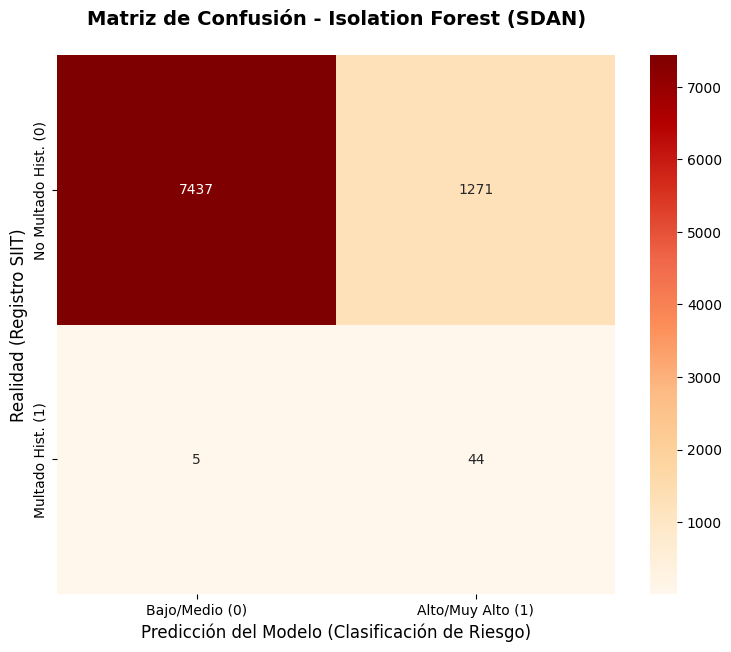

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score

# ==============================================================================
# FASE 1: CARGA DE LAS DOS BASES
# ==============================================================================
print("1. Cargando las bases para construir la Matriz de Confusión...")
# El archivo .xlsx que arrojó nuestro modelo Isolation Forest
df_resultados = pd.read_excel("/content/RESULTADO_FINAL_ISOLATION_FOREST.xlsx")
df_maestra = pd.read_csv("/content/BASE_MAESTRA_FINAL_REINFO.csv")
df_maestra.columns = df_maestra.columns.str.strip()

# Unir el Target Oculto (Multas Históricas) al resultado de la IA
df_cruce = pd.merge(df_resultados, df_maestra[['RUC', 'TARGET_INCUMPLIMIENTO']], on='RUC', how='left')
df_cruce['TARGET_INCUMPLIMIENTO'] = df_cruce['TARGET_INCUMPLIMIENTO'].fillna(0).astype(int)

# ==============================================================================
# FASE 2: CONSTRUCCIÓN DE LA LÓGICA DE CLASIFICACIÓN
# ==============================================================================
# Regla de Negocio: Si el modelo dice "ALTO RIESGO" o "MUY ALTO RIESGO", predecimos "1" (Anomalía)
df_cruce['PREDICCION_MODELO'] = df_cruce['NIVEL_DE_RIESGO'].apply(
    lambda x: 1 if x in ['MUY ALTO RIESGO', 'ALTO RIESGO'] else 0
)

y_real = df_cruce['TARGET_INCUMPLIMIENTO']
y_predicho = df_cruce['PREDICCION_MODELO']

# ==============================================================================
# FASE 3: CÁLCULO DE MÉTRICAS (RECALL, PRECISION, F1)
# ==============================================================================
cm = confusion_matrix(y_real, y_predicho)
recall = recall_score(y_real, y_predicho)
precision = precision_score(y_real, y_predicho)
f1 = f1_score(y_real, y_predicho)

print("\n================ MÉTRICAS DE EVALUACIÓN ================")
print(f"✅ VERDADEROS POSITIVOS (Evasores Atrapados): {cm[1,1]}")
print(f"❌ FALSOS NEGATIVOS (Evasores que escaparon): {cm[1,0]}")
print(f"✅ VERDADEROS NEGATIVOS (Empresas Limpias): {cm[0,0]}")
print(f"🔍 FALSOS POSITIVOS (SOSPECHOSOS DESCUBIERTOS): {cm[0,1]}")
print("--------------------------------------------------------")
print(f"🎯 RECALL (Capacidad de Captura): {recall:.2%}")
print(f"PRECISION (Concentración de infractores históricos): {precision:.2%}")
print(f"F1-SCORE: {f1:.4f}")
print("========================================================")

# ==============================================================================
# FASE 4: VISUALIZACIÓN GRÁFICA (MATRIZ DE CONFUSIÓN)
# ==============================================================================
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd',
            xticklabels=['Bajo/Medio (0)', 'Alto/Muy Alto (1)'],
            yticklabels=['No Multado Hist. (0)', 'Multado Hist. (1)'])

plt.title('Matriz de Confusión - Isolation Forest (SDAN)\n', fontsize=14, fontweight='bold')
plt.ylabel('Realidad (Registro SIIT)', fontsize=12)
plt.xlabel('Predicción del Modelo (Clasificación de Riesgo)', fontsize=12)

# Mostrar el gráfico (Ideal para capturar y pegar en tu PPT)
plt.show()

In [ ]:
import pandas as pd

# 1. Cargar el resultado final que ya generaste
# Asegúrate de que el nombre coincida con tu archivo actual
df = pd.read_excel("/content/RESULTADO_FINAL_ISOLATION_FOREST.xlsx")

# 2. Crear una función de semaforización visual (Emojis)
def asignar_semaforo(riesgo):
    if riesgo == 'MUY ALTO RIESGO':
        return '🔴' # Rojo (Prioridad Inspección Inmediata)
    elif riesgo == 'ALTO RIESGO':
        return '🟠' # Naranja (Cartas Inductivas)
    elif riesgo == 'RIESGO MEDIO':
        return '🟡' # Amarillo (Observación)
    else:
        return '🟢' # Verde (Normalidad)

# 3. Crear la nueva columna aplicando la función
df['SEMAFORO'] = df['NIVEL_DE_RIESGO'].apply(asignar_semaforo)

# 4. Reordenar las columnas (Opcional, para que el semáforo quede pegado al Riesgo)
# Si quieres dejarlo al final, puedes omitir esta línea
columnas = list(df.columns)
# Movemos el semáforo para que quede más visible
df = df[['RUC', 'SCORE_CRUDO', 'PROBABILIDAD_INCUMPLIMIENTO_%', 'NIVEL_DE_RIESGO', 'SEMAFORO']]

# 5. Exportar el nuevo Excel visual para la Gerencia
nombre_salida = "RESULTADO_SEMAFORIZADO_SDAN.xlsx"
df.to_excel(nombre_salida, index=False)

print(f"¡Listo! El archivo con los semáforos ha sido guardado como '{nombre_salida}'.")
# Mostramos una vista previa de los 5 primeros para confirmar
print("\nVista previa de cómo quedó:")
print(df.head(5).to_string())

¡Listo! El archivo con los semáforos ha sido guardado como 'RESULTADO_SEMAFORIZADO_SDAN.xlsx'.

Vista previa de cómo quedó:
           RUC  SCORE_CRUDO  PROBABILIDAD_INCUMPLIMIENTO_%  NIVEL_DE_RIESGO SEMAFORO
0  20131373075    -0.240632                         100.00  MUY ALTO RIESGO        🔴
1  20101259014    -0.239044                          99.63  MUY ALTO RIESGO        🔴
2  20131365994    -0.234828                          98.64  MUY ALTO RIESGO        🔴
3  20537630222    -0.233777                          98.40  MUY ALTO RIESGO        🔴
4  20131372931    -0.232204                          98.03  MUY ALTO RIESGO        🔴
